In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\karthik\OneDrive\Desktop\SMA TECH\Project\car_prices.csv", on_bad_lines='skip')

In [3]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [4]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558811.000000,547017.000000,558717.000000,558811.000000,558811.000000
mean,2010.038696,3.424512,68323.195797,13769.324646,13611.262461
std,3.966812,0.949439,53397.752933,9679.874607,9749.656919
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,2.700000,28374.000000,7100.000000,6900.000000
50%,2012.000000,3.600000,52256.000000,12250.000000,12100.000000
75%,2013.000000,4.200000,99112.000000,18300.000000,18200.000000
max,2015.000000,5.000000,999999.000000,182000.000000,230000.000000


In [5]:
df.isna().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65353
vin                 0
state               0
condition       11794
odometer           94
color             749
interior          749
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64

In [6]:
# Drop rows where either 'make' or 'model' is missing
df = df.dropna(subset=['make', 'model']).reset_index(drop=True)

# Optional check
df.isna().sum()

year                0
make                0
model               0
trim              350
body             2894
transmission    63586
vin                 0
state               0
condition       11707
odometer           90
color             729
interior          729
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64

In [7]:
df.drop(columns=['vin'], inplace=False).reset_index(drop=True)

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548407,2015,Kia,K900,Luxury,Sedan,NaN,in,4.5,18255.0,silver,black,avis corporation,35300,33000,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
548408,2012,Ram,2500,Power Wagon,Crew Cab,automatic,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200,30800,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
548409,2012,BMW,X5,xDrive35d,SUV,automatic,ca,4.8,50561.0,black,black,financial services remarketing (lease),29800,34000,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
548410,2015,Nissan,Altima,2.5 S,sedan,automatic,ga,3.8,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100,11100,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [8]:
df.replace({'transmission': {None: 'automatic'}}, inplace=False)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548407,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,4.5,18255.0,silver,black,avis corporation,35300,33000,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
548408,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200,30800,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
548409,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,4.8,50561.0,black,black,financial services remarketing (lease),29800,34000,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
548410,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,3.8,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100,11100,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [9]:
df.isna().sum()

year                0
make                0
model               0
trim              350
body             2894
transmission    63586
vin                 0
state               0
condition       11707
odometer           90
color             729
interior          729
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64

In [10]:
# Drop rows where either 'transmission', 'trim', 'body', 'odometer' is missing
df = df.dropna(subset=['transmission', 'trim', 'body', 'odometer']).reset_index(drop=True)

# Optional check
df.isna().sum()

year               0
make               0
model              0
trim               0
body               0
transmission       0
vin                0
state              0
condition       9399
odometer           0
color            576
interior         576
seller             0
mmr                0
sellingprice       0
saledate           0
dtype: int64

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'condition'}>],
       [<Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'mmr'}>],
       [<Axes: title={'center': 'sellingprice'}>, <Axes: >]], dtype=object)

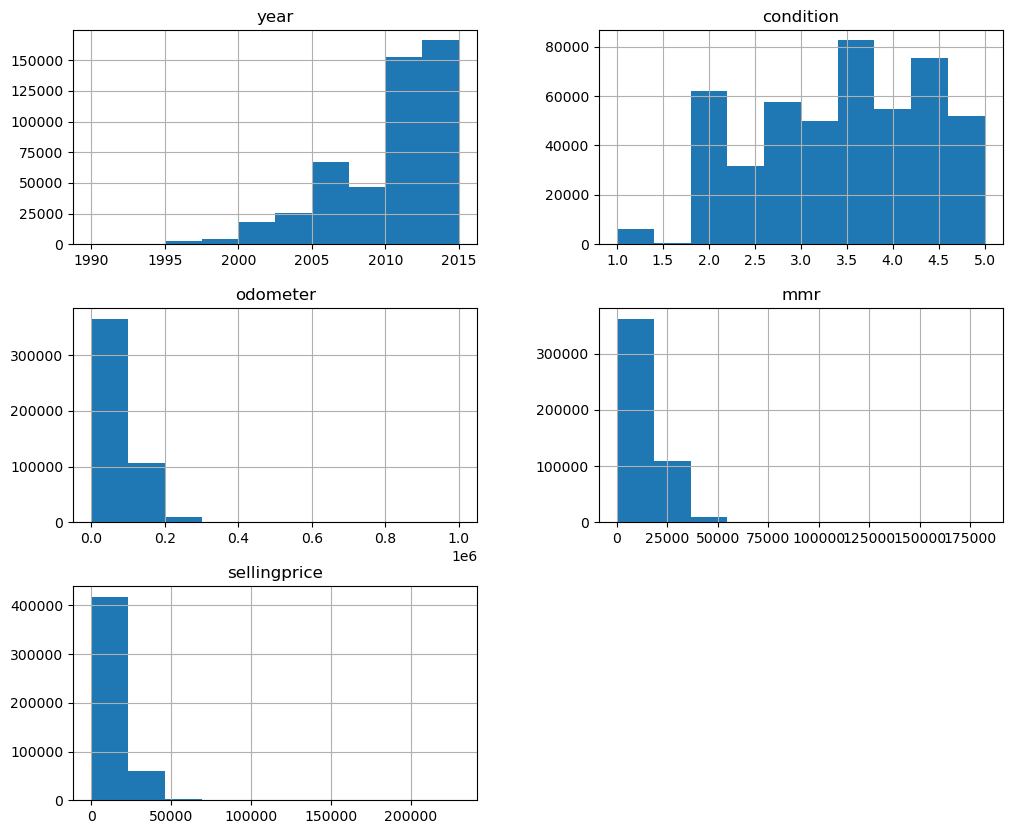

In [11]:
df.hist(figsize=(12, 10))

In [12]:
avg_condition = df['condition'].mean()
df['condition'] = df['condition'].fillna(avg_condition)
df.isna().sum()

year              0
make              0
model             0
trim              0
body              0
transmission      0
vin               0
state             0
condition         0
odometer          0
color           576
interior        576
seller            0
mmr               0
sellingprice      0
saledate          0
dtype: int64

In [13]:
interior_color = 'black'
color = 'black'
df['interior'] = df['interior'].fillna(interior_color)
df['color'] = df['color'].fillna(color)
df.isna().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'condition'}>],
       [<Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'mmr'}>],
       [<Axes: title={'center': 'sellingprice'}>, <Axes: >]], dtype=object)

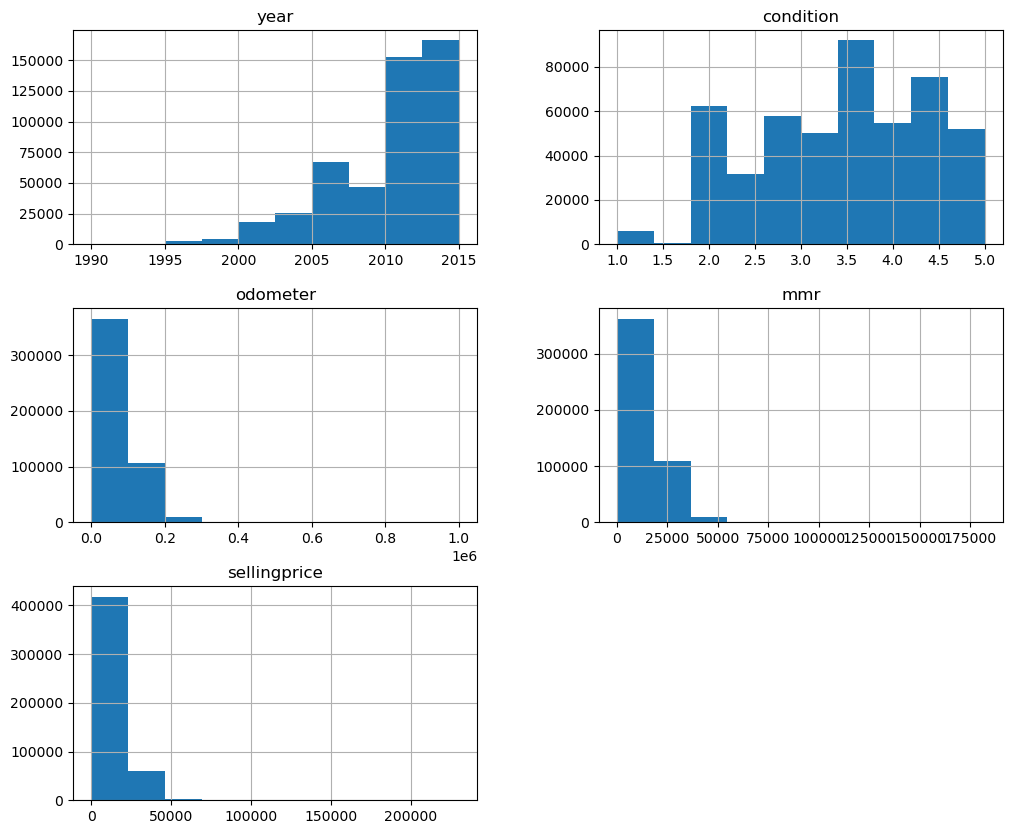

In [14]:
df.hist(figsize=(12, 10))

In [15]:
import sqlite3

conn = sqlite3.connect('assignment.db')

df.to_sql('car_prices', conn, if_exists='replace', index=False)
query = "SELECT * FROM car_prices"
df = pd.read_sql_query(query, conn)
print(df.head())

conn.commit()
conn.close()

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca        4.5    1331.0   gray    black   
3  yv1612tb4f1310987    ca        4.1   14282.0  white    black   
4  wba6b2c57ed129731    ca        4.3    2641.0   gray    black   

                                   seller    mmr  sellingprice  \
0                 kia motors america, inc  20500         21500   
1                 kia motors america, 

In [16]:
sale_year = df['saledate'].str[11:15].astype(int)
df['sale_year'] = sale_year
pop_cars = df.groupby(['sale_year', 'state', 'make', 'model']).size().reset_index(name='count')
pop_cars = pop_cars.sort_values(by='count', ascending=False)
pop_cars

,sale_year,state,make,model,count
9522,2015,fl,Nissan,Altima,3109
9633,2015,fl,Toyota,Camry,2442
8435,2015,ca,Nissan,Altima,2079
7961,2015,ca,BMW,3 Series,1940
9637,2015,fl,Toyota,Corolla,1861
...,...,...,...,...,...
4023,2014,ne,Acura,MDX,1
4022,2014,ne,Acura,CL,1
16728,2015,oh,GMC,Sierra 2500HD Classic,1
1974,2014,il,Cadillac,Escalade EXT,1


In [17]:
conn = sqlite3.connect('assignment.db')

df.to_sql('car_prices', conn, if_exists='replace', index=False)
query = "SELECT * FROM car_prices"
df = pd.read_sql_query(query, conn)
print(df.head())

conn.commit()
conn.close()

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca        4.5    1331.0   gray    black   
3  yv1612tb4f1310987    ca        4.1   14282.0  white    black   
4  wba6b2c57ed129731    ca        4.3    2641.0   gray    black   

                                   seller    mmr  sellingprice  \
0                 kia motors america, inc  20500         21500   
1                 kia motors america, 

In [18]:
# Create sale_month from saledate (month as integer: Jan=1, ..., Dec=12)
df['sale_month'] = pd.to_datetime(df['saledate'].str[4:7], format='%b').dt.month

# Remove the saledate column
df.drop(columns=['saledate'], inplace=True)

# Quick check
df[['sale_year', 'sale_month']].head()

,sale_year,sale_month
0,2014,12
1,2014,12
2,2015,1
3,2015,1
4,2014,12


In [19]:
conn = sqlite3.connect('assignment.db')

df.to_sql('car_prices', conn, if_exists='replace', index=False)
query = "SELECT * FROM car_prices"
df = pd.read_sql_query(query, conn)
print(df.head())

conn.commit()
conn.close()

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca        4.5    1331.0   gray    black   
3  yv1612tb4f1310987    ca        4.1   14282.0  white    black   
4  wba6b2c57ed129731    ca        4.3    2641.0   gray    black   

                                   seller    mmr  sellingprice  sale_year  \
0                 kia motors america, inc  20500         21500       2014   
1               